## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import logging
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set plotting style.
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
import helpers.hmatplotlib as hmatplo
import helpers.hmodule as hmodule
import helpers.hpandas_display as hpandisp

import msml610_utils as ut
import L08_01_causal_inference_utils as mtl0cireout

ut.config_notebook()

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
vim support installed: restart the notebook, if needed


Python 3.12.3
Linux d494b817c6e2 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 aarch64 aarch64 GNU/Linux


In [3]:
hmodule.install_module_if_not_present(
  "dataframe_image",
  use_activate=True,
)

Module 'dataframe_image' is already installed.


# Cell 1: Sales example

In [4]:
dir_name = "L08_data"
#!ls $dir_name

out_dir_name = "figures/"

markdown_path_prefix="msml610/lectures_source"
# cp msml610/lectures_source/figures/L08*.png msml610/lectures_source/figures

In [5]:
data = mtl0cireout.load_xmas_sales_data(dir_name)
print(data.shape)
data.head(6)

(2000, 5)


,store,weeks_to_xmas,avg_week_sales,is_on_sale,weekly_amount_sold
0,1,3,12.98,1.0,219.60
1,1,2,12.98,1.0,184.70
2,1,1,12.98,1.0,145.75
3,1,0,12.98,0.0,102.45
4,2,3,19.92,0.0,103.22
5,2,2,19.92,0.0,53.73


In [6]:
xmas_sales_df_png = os.path.join(out_dir_name, 'L08.4.xmas_sales_df.png')
hpandisp.convert_df_to_png(
    data.head(6),
    xmas_sales_df_png,
    index=True,
    print_markdown=True,
    markdown_path_prefix=markdown_path_prefix
)

PNG image saved to: 'figures/L08.4.xmas_sales_df.png'
![](msml610/lectures_source/figures/L08.4.xmas_sales_df.png)


- **Purpose**: Compare sales outcomes between stores with and without price cuts
- **What it shows**: Box plots of weekly sales amounts for treated (cut prices) and control (no price cut) groups
- **Key insight**: Visual evidence suggesting price cuts increase sales, but this may reflect confounding rather than true causal effect

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Saved figure to 'figures/L08.4.xmas_boxplot.png'
![](msml610/lectures_source/figures/L08.4.xmas_boxplot.png)


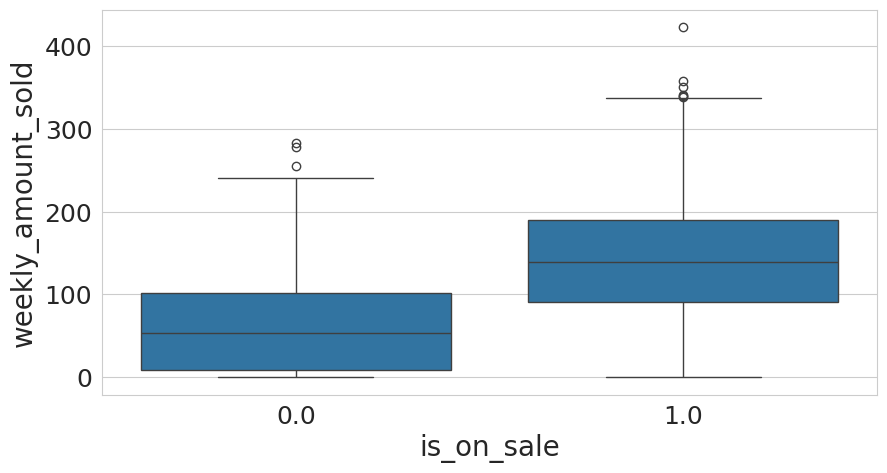

In [7]:
fig = mtl0cireout.plot_xmas_sales_boxplot(data)
xmas_boxplot_png = os.path.join(out_dir_name, "L08.4.xmas_boxplot.png")
hmatplo.save_fig(
    fig,
    xmas_boxplot_png,
    print_markdown=True,
    path_prefix=markdown_path_prefix
)

## Cell 2: Conceptual Example

In [8]:
# # i = unit identifier
# # y0, y1 = outcomes under control and treatment
# # t = treatment indicator
# # x = group
# df1 = pd.DataFrame(
#     dict(
#         i=[1, 2, 3, 4, 5, 6],
#         y0=[200, 120, 300, 450, 600, 600],
#         y1=[220, 140, 400, 500, 600, 800],
#         t=[0, 0, 0, 1, 1, 1],
#         x=[0, 0, 1, 0, 0, 1],
#     )
# )
# df1

In [9]:
# # Select the outcome based on the treatment.
# df1["y"] = (df1["t"] * df1["y1"] + (1 - df1["t"]) * df1["y0"]).astype(int)

# # Treatment effect.
# df1["te"] = df1["y1"] - df1["y0"]

# df1

In [10]:
# df2 = pd.DataFrame(
#     dict(
#         i=[1, 2, 3, 4, 5, 6],
#         y0=[
#             200,
#             120,
#             300,
#             np.nan,
#             np.nan,
#             np.nan,
#         ],
#         y1=[np.nan, np.nan, np.nan, 500, 600, 800],
#         t=[0, 0, 0, 1, 1, 1],
#         x=[0, 0, 1, 0, 0, 1],
#     )
# )
# df2

In [11]:
# # Select the outcome based on the treatment.
# df2["y"] = (df2["t"] * df2["y1"] + (1 - df2["t"]) * df2["y0"]).astype(int)

# # Treatment effect.
# df2["te"] = df2["y1"] - df2["y0"]

# df2

## Cell 3: Visual Analysis of Bias in Sales Example

- **Purpose**: Visualize scatter points and regression lines for treated and control stores
- **What it shows**: Treated stores (red) and control stores (blue) with their respective regression trends
- **Key insight**: Within each group, the relationship between baseline sales and treatment appears similar, but overall pooled relationship is different

Saved figure to 'figures/L08.4.Association_Causation_Bias0.png'
![](msml610/lectures_source/figures/L08.4.Association_Causation_Bias0.png)


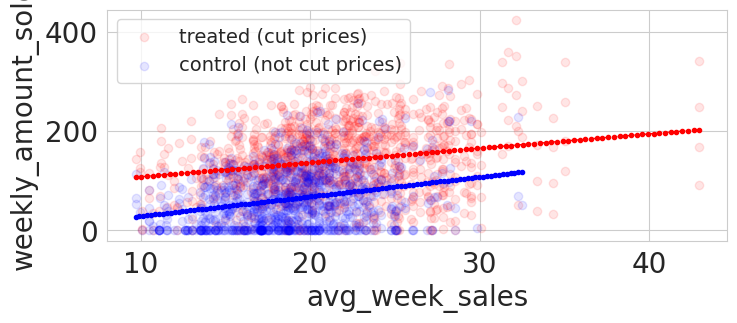

In [12]:
fig = mtl0cireout.plot_sales_bias_analysis(data)
bias_analysis0_png = os.path.join(out_dir_name, "L08.4.Association_Causation_Bias0.png")
hmatplo.save_fig(
    fig,
    bias_analysis0_png,
    print_markdown=True,
    path_prefix=markdown_path_prefix
)

- **Purpose**: Compare pooled vs. stratified regression models with synthetic data
- **What it shows**: Left panel shows single trend line across all data; right panel shows separate trend lines for large and small businesses
- **Key insight**: Simpson's paradox emerges when aggregation obscures group-level trends; stratification reveals the true relationships

Saved figure to 'figures/L08.4.Association_Causation_Bias1.png'
![](msml610/lectures_source/figures/L08.4.Association_Causation_Bias1.png)


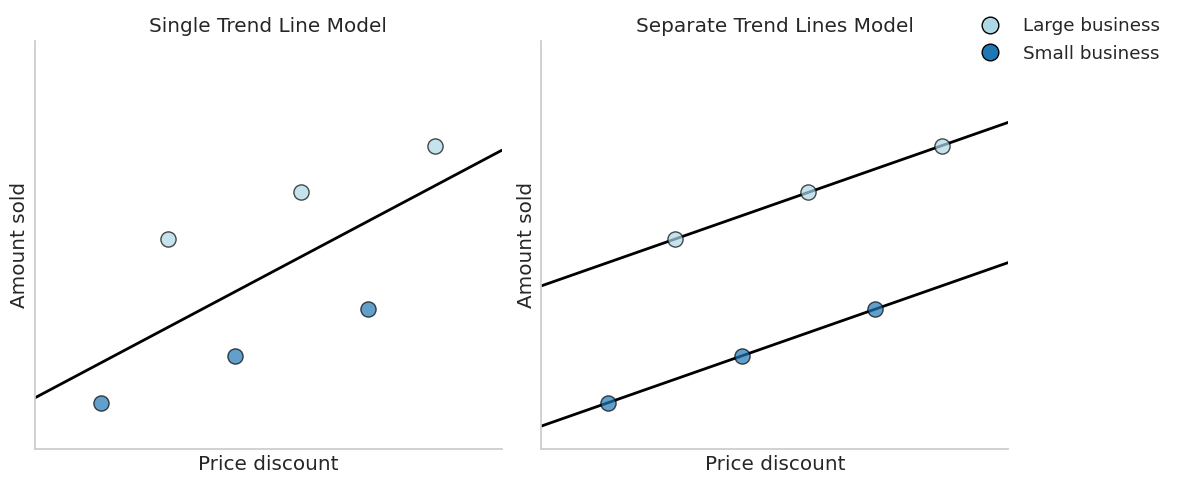

In [13]:
fig = mtl0cireout.plot_single_vs_separate_trends()
bias_analysis1_png = os.path.join(out_dir_name, "L08.4.Association_Causation_Bias1.png")
hmatplo.save_fig(
    fig,
    bias_analysis1_png,
    print_markdown=True,
    path_prefix=markdown_path_prefix
)

## Cell 4: Simpson's Paradox

- **Purpose**: Illustrate Simpson's paradox where aggregate and group-level trends contradict
- **What it shows**: Two groups (blue and red) with positive within-group trends, but negative overall trend
- **Key insight**: Ignoring confounding variables (like business size) leads to contradictory causal conclusions

Saved figure to 'figures/L08.4.Simpson_Paradox.png'
![](msml610/lectures_source/figures/L08.4.Simpson_Paradox.png)


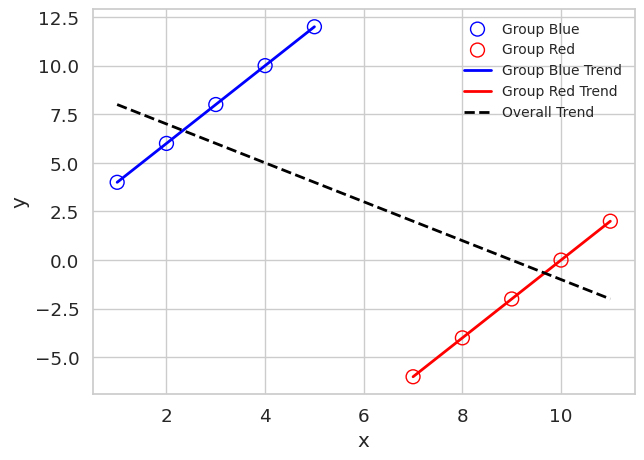

In [14]:
fig = mtl0cireout.plot_simpsons_paradox()
simpsons_paradox_png = os.path.join(out_dir_name, "L08.4.Simpson_Paradox.png")
hmatplo.save_fig(
    fig,
    simpsons_paradox_png,
    print_markdown=True,
    path_prefix=markdown_path_prefix
)

## Cell 5: University Simpson's Paradox

- **Purpose**: Demonstrate Simpson's paradox in university admissions context with two different groups
- **What it shows**: Left panel shows two groups (A and B) each with positive admission trends; right panel shows aggregated data with reversed negative overall trend
- **Key insight**: Simpson's paradox reveals how ignoring group differences (e.g., selectivity, baseline rates) leads to reversed causal conclusions in aggregate data

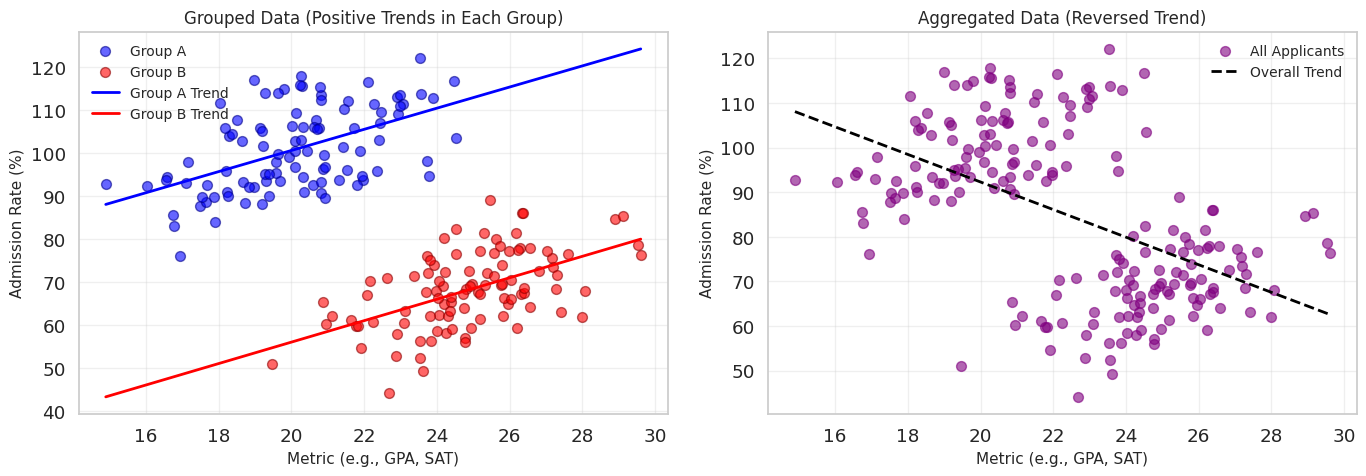

In [15]:
fig = mtl0cireout.plot_university_simpsons_paradox()